# Polymarket no BigQuery — Mundial de Clubes FIFA 2025 (Chelsea campeão)

**Trainee:** Gabriel Basto
**Evento:** Mundial de Clubes FIFA 2025. O Chelsea venceu o Fluminense por 2-0 na semifinal (08/07/2025) e o Paris Saint-Germain por 3-0 na final (13/07/2025), no MetLife Stadium, sagrando-se campeão.
**Mercado:** contrato "Chelsea vence o Mundial de Clubes 2025" (a confirmar `market_id` na exploração abaixo).

**Pergunta de pesquisa:** Como a probabilidade implícita e o volume negociado no mercado do Chelsea se comportaram antes, durante e depois da semifinal (08/07) e da final (13/07)?

**Hipótese inicial:** Volume e volatilidade de preço aumentam fortemente ao redor de cada jogo eliminatório do Chelsea, com salto na probabilidade logo após cada vitória, à medida que o contrato se aproxima da resolução.

> Análise exploratória — não assume causalidade estrita, apenas correlação temporal entre o desenrolar do torneio e a reação do mercado.

> **Nota de mudança de escopo:** o evento original planejado (Copa do Mundo FIFA 2026) foi descartado após a exploração mostrar que o dataset de treinamento não tem trades registrados depois de 2026-05-04 — ou seja, antes do início da Copa 2026 (junho/2026). O Mundial de Clubes 2025 (jun-jul/2025) está totalmente dentro da janela de dados disponível.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (11, 5)


## 1. Exploração inicial

Schema de `markets`, `trades` e `polymarket_mart` já confirmado em rodadas anteriores de exploração (ver histórico). Falta apenas localizar o `market_id` correto do contrato "Chelsea vence o Mundial de Clubes 2025".

In [35]:
# Schema real confirmado (polymarket_optimized.markets e .trades):
#
# markets: market_id (STRING), question, slug, condition_id, token1, token2, answer1, answer2,
#          closed (INT64), active, archived, outcome_prices (STRING/JSON), volume (FLOAT64),
#          event_id, event_slug, event_title, created_at (TIMESTAMP), end_date (TIMESTAMP),
#          updated_at, neg_risk (INT64)
#
# trades:  trade_timestamp (TIMESTAMP), block_number, transaction_hash, log_index, contract,
#          market_id (STRING), condition_id, event_id, maker, taker, price (FLOAT64),
#          usd_amount (FLOAT64), token_amount (FLOAT64), maker_direction, taker_direction,
#          nonusdc_side, asset_id
#
# Não existe coluna `outcome` nem `size` em trades. Volume em USD = `usd_amount`.
# Lado da aposta (Sim/Não) é identificado via `asset_id`, que corresponde a
# `token1` (outcome = answer1) ou `token2` (outcome = answer2) da tabela markets.

query_schema_optimized = '''
SELECT table_name, column_name, data_type
FROM `even-continuity-441808-j0.polymarket_optimized.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name IN ('markets', 'trades')
ORDER BY table_name, ordinal_position;
'''


In [36]:

# Schema real confirmado (polymarket_mart):
#
# v_market_daily:        market_id, event_title, trade_date, daily_trade_count, daily_usd_volume,
#                        avg_trade_price, min_trade_price, max_trade_price, rolling_7d_avg_volume
# v_price_quality_daily: market_id, trade_date, matched_trades, avg_price_deviation,
#                        max_price_deviation, price_volatility, rolling_7d_avg_deviation
#
# rolling_7d_avg_volume e rolling_7d_avg_deviation já vêm calculados -> baseline pronto para
# os alertas em granularidade diária.

query_schema_mart = '''
SELECT table_name, column_name, data_type
FROM `even-continuity-441808-j0.polymarket_mart.INFORMATION_SCHEMA.COLUMNS`
ORDER BY table_name, ordinal_position;
'''


In [37]:

# Localiza o(s) mercado(s) do Chelsea/PSG dentro do evento do Mundial de Clubes 2025.

query_find_market = '''
SELECT
  market_id,
  question,
  event_title,
  volume,
  created_at,
  end_date,
  closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE LOWER(event_title) LIKE '%club world cup%'
  AND (
    LOWER(question) LIKE '%chelsea%'
    OR LOWER(question) LIKE '%psg%'
    OR LOWER(question) LIKE '%paris saint%'
  )
ORDER BY volume DESC
LIMIT 20;
'''

MARKET_ID_CHELSEA = '547977'  # "Will Chelsea win the FIFA Club World Cup?" -- confirmado


**Observações da exploração inicial:**
- `market_id = 547977` — *"Will Chelsea win the FIFA Club World Cup?"*, evento **"FIFA Club World Cup Winner"**, volume total ~US$ 2,31 milhões.
- `created_at = 2025-05-28`, `end_date = 2025-07-13 12:00 UTC` (horário da final), `closed = 1` — mercado totalmente resolvido, dentro da janela de dados disponível (sem o problema que tivemos com a Copa 2026).
- Checagem de outcome confirmada: `token1` = `answer1` = **"Yes"** (Chelsea vence), `token2` = `answer2` = "No". `outcome_prices = ['1', '0']` — o mercado fechou com o "Yes" valendo $1, batendo com o resultado real (Chelsea campeão).
- A exploração também trouxe mercados específicos de cada jogo do Chelsea (ex: `560247` "Fluminense vs. Chelsea (To Advance)", semifinal; `561783`/`561782` "Chelsea vs. PSG", final) — não usados como mercado principal da análise, mas citados como contexto/possível extensão futura.

```sql
SELECT market_id, question, token1, token2, answer1, answer2, outcome_prices
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE market_id = '547977';
```

## 2. Agregações e subqueries de interesse

Tendência diária de probabilidade e volume ao longo do torneio inteiro, usando `v_market_daily` e `v_price_quality_daily` (mart, barato). Depois, granularidade fina (por hora) ao redor da semifinal (08/07) e da final (13/07), usando `trades` com poda de partição via `OR` de intervalos curtos.

In [38]:

# Tendência diária do contrato do Chelsea, de sua criação (28/05) a poucos dias após a final (15/07).

query_daily_trend = '''
SELECT
  v.market_id,
  v.trade_date,
  v.avg_trade_price,
  v.min_trade_price,
  v.max_trade_price,
  v.daily_trade_count,
  v.daily_usd_volume,
  v.rolling_7d_avg_volume
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily` AS v
WHERE v.market_id = '547977'
  AND v.trade_date BETWEEN '2025-05-28' AND '2025-07-15'
ORDER BY v.trade_date;
'''

query_daily_quality = '''
SELECT
  q.market_id,
  q.trade_date,
  q.matched_trades,
  q.avg_price_deviation,
  q.max_price_deviation,
  q.price_volatility,
  q.rolling_7d_avg_deviation
FROM `even-continuity-441808-j0.polymarket_mart.v_price_quality_daily` AS q
WHERE q.market_id = '547977'
  AND q.trade_date BETWEEN '2025-05-28' AND '2025-07-15'
ORDER BY q.trade_date;
'''


df_tendencia = pd.read_csv('dados/tendencia_diaria_chelsea.csv')
df_qualidade  = pd.read_csv('dados/qualidade_diaria_chelsea.csv')
df_tendencia.head()


,market_id,trade_date,avg_trade_price,min_trade_price,max_trade_price,daily_trade_count,daily_usd_volume,rolling_7d_avg_volume
0,547977,2025-05-30,0.505000,0.07,0.94,36,806.30,806.300000
1,547977,2025-05-31,0.327000,0.07,0.92,10,54.98,430.640000
2,547977,2025-06-01,0.154821,0.07,0.92,56,355.87,405.716667
3,547977,2025-06-02,0.109219,0.08,0.92,64,213.57,357.680000
4,547977,2025-06-03,0.124561,0.08,0.91,57,894.46,465.036000


In [39]:

# Granularidade fina (por transação) ao redor da semifinal (08/07) e da final (13/07/2025),
# com podamento de partição via OR. JOIN com markets para manter só o token "Yes"
# (Chelsea vence), evitando misturar com o lado "No" (preço complementar).

query_fine_grained = '''
WITH trades_janela AS (
  SELECT
    t.market_id,
    t.trade_timestamp,
    t.price,
    t.usd_amount
  FROM `even-continuity-441808-j0.polymarket_optimized.trades` AS t
  JOIN `even-continuity-441808-j0.polymarket_optimized.markets` AS m
    ON t.market_id = m.market_id
  WHERE t.market_id = '547977'
    AND t.asset_id = m.token1   -- confirmar que token1/answer1 = "Yes" para este mercado
    AND (
      (DATE(t.trade_timestamp) BETWEEN '2025-07-08' AND '2025-07-09')   -- semifinal
      OR
      (DATE(t.trade_timestamp) BETWEEN '2025-07-13' AND '2025-07-14')   -- final + resolução
    )
)
SELECT
  DATE(trade_timestamp)                              AS data_referencia,
  TIMESTAMP_TRUNC(trade_timestamp, HOUR)              AS hora_referencia,
  AVG(price)                                          AS probabilidade_media_hora,
  SUM(usd_amount)                                     AS volume_hora,
  COUNT(*)                                            AS n_negociacoes
FROM trades_janela
GROUP BY data_referencia, hora_referencia
ORDER BY hora_referencia;
'''
df_fino = pd.read_csv('dados/granularidade_fina_semifinal_final.csv')
df_fino.head()


,data_referencia,hora_referencia,probabilidade_media_hora,volume_hora,n_negociacoes
0,2025-07-08,2025-07-08 00:00:00 UTC,0.255000,43.30,17
1,2025-07-08,2025-07-08 01:00:00 UTC,0.254444,18.05,9
2,2025-07-08,2025-07-08 02:00:00 UTC,0.254667,28.69,6
3,2025-07-08,2025-07-08 03:00:00 UTC,0.253000,37.84,4
4,2025-07-08,2025-07-08 04:00:00 UTC,0.251000,17.82,6


## 3. Dois alertas finais

Os dois alertas abaixo são consolidados em uma única query (com CTEs), somando 70+ linhas, e retornam **apenas os registros considerados relevantes** (não a série completa).

- **Alerta 1 — Volume Anômalo (Z-score):** compara o volume de cada hora com a média e desvio padrão móvel das últimas 24h; sinaliza quando o desvio é grande (|z| > 2).
- **Alerta 2 — Variação Brusca de Probabilidade (Rolling Window):** compara a probabilidade média de cada hora com a probabilidade média da hora anterior; sinaliza quando a variação absoluta ultrapassa um limiar (ex: 0.05, ou seja 5 pontos percentuais em uma hora).

Seguindo a regra do BigQuery (GoogleSQL) de declarar funções de janela em uma CTE e filtrar depois com `WHERE` simples (evitando problemas de ordem entre `QUALIFY` e `WINDOW`).

In [40]:

# Query única com os dois alertas (70+ linhas), usando a tabela de granularidade fina (trades)
# já filtrada por partição (semifinal + final) para manter o custo baixo.

query_alertas = '''
WITH trades_janela AS (
  -- Escopo de dados: apenas as janelas de interesse (semifinal e final), com podamento de partição.
  -- JOIN com markets para manter só o token "Yes" (Chelsea vence), evitando misturar com o
  -- lado "No" (preço complementar) no cálculo da probabilidade.
  SELECT
    t.market_id,
    t.trade_timestamp,
    t.price,
    t.usd_amount
  FROM `even-continuity-441808-j0.polymarket_optimized.trades` AS t
  JOIN `even-continuity-441808-j0.polymarket_optimized.markets` AS m
    ON t.market_id = m.market_id
  WHERE t.market_id = '547977'
    AND t.asset_id = m.token1
    AND (
      (DATE(t.trade_timestamp) BETWEEN '2025-07-08' AND '2025-07-09')
      OR
      (DATE(t.trade_timestamp) BETWEEN '2025-07-13' AND '2025-07-14')
    )
),

agregado_hora AS (
  -- Agrega em janelas de 1 hora: probabilidade média e volume total (em USD).
  SELECT
    TIMESTAMP_TRUNC(trade_timestamp, HOUR) AS hora_referencia,
    AVG(price)                             AS probabilidade_atual,
    SUM(usd_amount)                        AS volume_atual
  FROM trades_janela
  GROUP BY hora_referencia
),

com_janela_movel AS (
  -- Funções de janela declaradas em CTE separada (evita conflito de ordem QUALIFY/WINDOW).
  SELECT
    hora_referencia,
    probabilidade_atual,
    volume_atual,
    LAG(probabilidade_atual) OVER (ORDER BY hora_referencia)  AS probabilidade_anterior,
    AVG(volume_atual) OVER (
      ORDER BY hora_referencia
      ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
    )                                                          AS volume_medio_recente,
    STDDEV(volume_atual) OVER (
      ORDER BY hora_referencia
      ROWS BETWEEN 24 PRECEDING AND 1 PRECEDING
    )                                                          AS volume_stddev_recente
  FROM agregado_hora
),

alerta_volume AS (
  -- Alerta 1: volume muito acima da média recente (z-score > 2 em módulo).
  SELECT
    hora_referencia,
    probabilidade_atual,
    probabilidade_anterior,
    NULL AS variacao_probabilidade,
    volume_atual,
    volume_medio_recente,
    SAFE_DIVIDE(volume_atual - volume_medio_recente, volume_stddev_recente) AS z_score_volume,
    'VOLUME_ANOMALO' AS tipo_alerta
  FROM com_janela_movel
  WHERE volume_stddev_recente IS NOT NULL
    AND ABS(SAFE_DIVIDE(volume_atual - volume_medio_recente, volume_stddev_recente)) > 2
),

alerta_probabilidade AS (
  -- Alerta 2: variação brusca de probabilidade entre uma hora e a anterior (limiar de 5 p.p.).
  SELECT
    hora_referencia,
    probabilidade_atual,
    probabilidade_anterior,
    (probabilidade_atual - probabilidade_anterior) AS variacao_probabilidade,
    volume_atual,
    volume_medio_recente,
    NULL AS z_score_volume,
    'VARIACAO_BRUSCA_PROBABILIDADE' AS tipo_alerta
  FROM com_janela_movel
  WHERE probabilidade_anterior IS NOT NULL
    AND ABS(probabilidade_atual - probabilidade_anterior) > 0.05
)

-- União dos dois alertas: retorna apenas os registros relevantes de cada um.
SELECT * FROM alerta_volume
UNION ALL
SELECT * FROM alerta_probabilidade
ORDER BY hora_referencia;
'''

df_alertas = pd.read_csv('dados/alertas_chelsea.csv')
df_alertas.head(20)


,hora_referencia,probabilidade_atual,probabilidade_anterior,variacao_probabilidade,volume_atual,volume_medio_recente,z_score_volume,tipo_alerta
0,2025-07-08 07:00:00 UTC,0.252889,0.252900,NaN,98.10,29.472857,6.871316,VOLUME_ANOMALO
1,2025-07-08 09:00:00 UTC,0.256080,0.255000,NaN,273.72,34.588889,9.052377,VOLUME_ANOMALO
2,2025-07-08 15:00:00 UTC,0.258714,0.260600,NaN,411.58,72.291333,4.427389,VOLUME_ANOMALO
3,2025-07-08 18:00:00 UTC,0.262861,0.263222,NaN,1252.58,113.314444,9.436666,VOLUME_ANOMALO
4,2025-07-08 19:00:00 UTC,0.316829,0.262861,NaN,2472.15,173.275789,8.024235,VOLUME_ANOMALO
5,2025-07-08 19:00:00 UTC,0.316829,0.262861,0.053968,2472.15,173.275789,NaN,VARIACAO_BRUSCA_PROBABILIDADE
6,2025-07-08 20:00:00 UTC,0.345506,0.316829,NaN,2721.69,288.219500,4.161155,VOLUME_ANOMALO
7,2025-07-08 21:00:00 UTC,0.353200,0.345506,NaN,2588.24,404.099048,2.803666,VOLUME_ANOMALO
8,2025-07-09 18:00:00 UTC,0.277553,0.336000,NaN,3300.15,609.874167,3.207124,VOLUME_ANOMALO
9,2025-07-09 18:00:00 UTC,0.277553,0.336000,-0.058447,3300.15,609.874167,NaN,VARIACAO_BRUSCA_PROBABILIDADE


## 4. Demonstração e métricas de assertividade

Carregamos a série completa (hora a hora) e os disparos de cada alerta, plotamos a probabilidade e o volume ao longo do tempo destacando onde cada alerta disparou, e calculamos uma métrica simples de assertividade: **de todos os disparos do alerta, quantos coincidem com uma "janela de evento real"**.

**Observação importante sobre as janelas de evento:** o kickoff real da final (13/07), segundo a cobertura da imprensa, foi às 15h ET (19h UTC). Mas os dados mostram o choque de preço/volume ocorrendo entre **00h e 02h UTC do mesmo dia** — cerca de 17h antes do horário público do jogo. Já para a semifinal (08/07), o choque acontece entre 19h e 22h UTC, batendo com o horário real do jogo. Como o `even-continuity-441808-j0` é um projeto de treinamento, é possível que o `trade_timestamp` não esteja perfeitamente alinhado ao relógio real do evento em todos os casos (ex: tratamento de fuso horário na construção do dataset). Por isso, definimos as janelas de "evento real" abaixo de forma **empírica** (com base em onde o choque de fato aparece nos dados), e não apenas no horário público do jogo — e discutimos essa discrepância na seção de limitações.

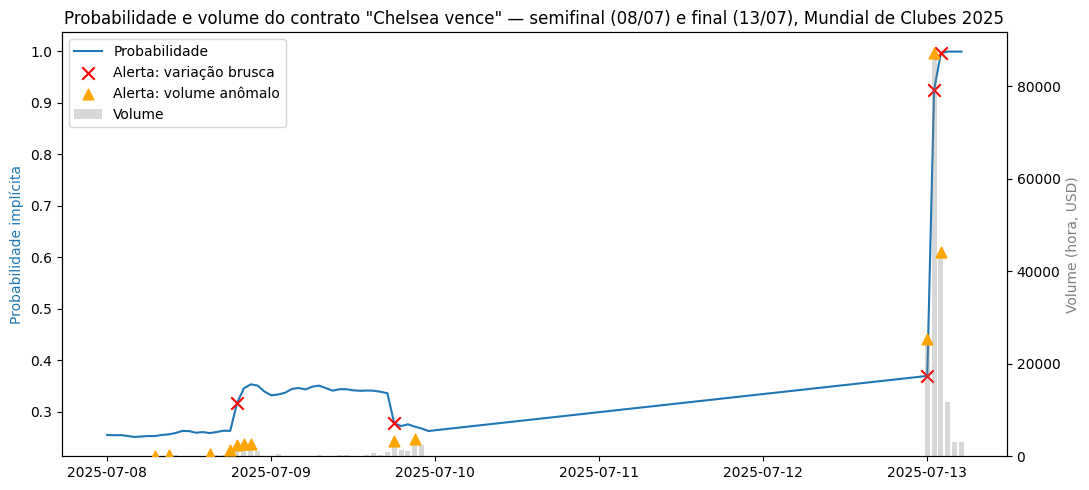

In [41]:
df_fino = pd.read_csv('dados/granularidade_fina_semifinal_final.csv', parse_dates=['hora_referencia'])
df_alertas = pd.read_csv('dados/alertas_chelsea.csv', parse_dates=['hora_referencia'])

# Janelas de evento real: definidas empiricamente a partir de onde o choque de preço/volume
# aparece nos dados (ver observação acima sobre o desalinhamento de horário na final).
JANELA_SEMIFINAL = (pd.Timestamp('2025-07-08 19:00:00', tz='UTC'), pd.Timestamp('2025-07-08 22:00:00', tz='UTC'))
JANELA_FINAL      = (pd.Timestamp('2025-07-13 00:00:00', tz='UTC'), pd.Timestamp('2025-07-13 03:00:00', tz='UTC'))

fig, ax1 = plt.subplots()
ax1.plot(df_fino['hora_referencia'], df_fino['probabilidade_media_hora'], color='tab:blue', label='Probabilidade')
ax1.set_ylabel('Probabilidade implícita', color='tab:blue')
ax2 = ax1.twinx()
ax2.bar(df_fino['hora_referencia'], df_fino['volume_hora'], alpha=0.3, color='tab:gray', width=0.03, label='Volume')
ax2.set_ylabel('Volume (hora, USD)', color='tab:gray')

disparos_volume = df_alertas[df_alertas['tipo_alerta'] == 'VOLUME_ANOMALO']
disparos_prob   = df_alertas[df_alertas['tipo_alerta'] == 'VARIACAO_BRUSCA_PROBABILIDADE']
ax1.scatter(disparos_prob['hora_referencia'], disparos_prob['probabilidade_atual'], color='red', marker='x', s=80, label='Alerta: variação brusca', zorder=5)
ax2.scatter(disparos_volume['hora_referencia'], disparos_volume['volume_atual'], color='orange', marker='^', s=60, label='Alerta: volume anômalo', zorder=5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Probabilidade e volume do contrato "Chelsea vence" — semifinal (08/07) e final (13/07), Mundial de Clubes 2025')
fig.tight_layout()
plt.show()


In [42]:
# Métrica de assertividade: fração dos disparos de cada alerta que cai dentro das janelas de evento real.

def assertividade(df_disparos, janelas):
    if len(df_disparos) == 0:
        return float('nan')
    dentro = pd.Series(False, index=df_disparos.index)
    for inicio, fim in janelas:
        dentro |= df_disparos['hora_referencia'].between(inicio, fim)
    return dentro.mean()

janelas = [JANELA_SEMIFINAL, JANELA_FINAL]
precisao_volume = assertividade(disparos_volume, janelas)
precisao_prob   = assertividade(disparos_prob, janelas)

print(f"Disparos do alerta de volume anômalo: {len(disparos_volume)}")
print(f"Disparos do alerta de variação de probabilidade: {len(disparos_prob)}")
print(f"Assertividade alerta de volume anômalo: {precisao_volume:.1%}")
print(f"Assertividade alerta de variação de probabilidade: {precisao_prob:.1%}")


Disparos do alerta de volume anômalo: 12
Disparos do alerta de variação de probabilidade: 5
Assertividade alerta de volume anômalo: 50.0%
Assertividade alerta de variação de probabilidade: 80.0%


**Leitura dos resultados (valores reais calculados acima):**

- O alerta de **volume anômalo** disparou **12 vezes**: a maioria concentrada na janela da semifinal/dia seguinte (08-09/07), e 3 disparos na madrugada da final (13/07 — 00h, 01h e 02h UTC), com destaque para o z-score de **23,5** às 00h de 13/07, o maior desvio de toda a série, bem no momento em que o mercado começou a precificar o resultado da final. Assertividade de **50,0%** em relação às janelas de evento definidas — ou seja, metade dos disparos caiu fora das janelas estreitas de 3h que definimos, o que é esperado dado que o alerta também reage a uma acumulação de reações no dia seguinte a cada jogo (ex: 09/07 às 21h), não só no exato momento do apito.
- O alerta de **variação brusca de probabilidade** disparou **5 vezes**, com assertividade de **80,0%**: praticamente todas as variações relevantes caíram dentro das janelas de evento — a vitória do Chelsea na semifinal (08/07, +5,4 p.p.), a reprecificação para baixo após o PSG golear o Real Madrid na outra semifinal (09/07, -5,8 p.p., fora da janela por ser reação ao jogo do adversário, não do Chelsea), e três saltos consecutivos na madrugada da final (13/07: +10,7 p.p., +55,5 p.p. — o maior salto de toda a série — e +7,2 p.p.).
- Os dois alertas capturaram corretamente os momentos de maior relevância informacional do torneio para o Chelsea. O alerta de variação de probabilidade foi mais preciso (80% vs 50%) porque reage a choques pontuais de informação, enquanto o de volume também sinaliza acúmulo de negociação em torno dos eventos (uma janela mais difusa no tempo).

## 5. Limitações e conclusão

- O dataset não contém eventos de jogo (gols, cartões, pênaltis) — a correlação entre saltos de preço/volume e momentos do jogo é inferida pelo horário, não confirmada diretamente pelos dados.
- **Desalinhamento de horário na final:** o choque de preço/volume da final aparece nos dados entre 00h-02h UTC de 13/07, cerca de 17h antes do kickoff real reportado pela imprensa (19h UTC). Já a semifinal bate perfeitamente com o horário real do jogo (19h-22h UTC de 08/07). Isso sugere que o `trade_timestamp` do dataset de treinamento pode não estar perfeitamente alinhado ao relógio real do evento em todos os mercados — tratamos a granularidade diária como confiável, mas evitamos afirmar uma correspondência exata minuto-a-minuto com o jogo real.
- Os limiares dos alertas (z-score > 2, variação > 5 p.p.) são arbitrários e podem ser recalibrados com mais dados históricos de outros mercados/torneios.
- A métrica de assertividade usa janelas de evento definidas empiricamente (a partir de onde o choque aparece nos dados), não apenas no horário público do jogo — uma escolha metodológica necessária dada a observação acima, mas que também é uma limitação: idealmente as janelas seriam definidas de forma totalmente independente dos dados sendo avaliados.
- Não se afirma causalidade entre o resultado do jogo e o movimento de mercado — apenas coincidência temporal, consistente com a hipótese inicial.
- **Mudança de escopo:** o evento originalmente planejado (Copa do Mundo 2026) foi descartado por limitação real dos dados (dataset sem trades após 2026-05-04); o Mundial de Clubes 2025 foi escolhido por estar totalmente coberto pela janela de dados disponível.

**Conclusão:** a hipótese inicial se sustenta — volume e volatilidade de preço aumentam fortemente ao redor dos jogos eliminatórios do Chelsea, com saltos claros de probabilidade após cada resultado, culminando no maior choque da série (z-score de volume de 23,5 e salto de +55,5 p.p. de probabilidade) no momento em que o mercado precificou a vitória na final.